<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset info:")
df.info()

print("\nSummary statistics:")
print(df.describe(include='all'))

Shape of dataset:
(65437, 114)

Column names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHave

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
print("Missing values before handling:")
print(df.isnull().sum().sort_values(ascending=False))

df['Employment'] = df['Employment'].fillna(df['Employment'].mode()[0])
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])

if 'JobSat' in df.columns:
    df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
    df['JobSat'] = df['JobSat'].fillna(df['JobSat'].median())

if 'YearsCodePro' in df.columns:
    df['YearsCodePro'] = df['YearsCodePro'].replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
    df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].median())

print("\nMissing values after handling:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values before handling:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Age                               0
Employment                        0
Check                             0
ResponseId                        0
Length: 114, dtype: int64

Missing values after handling:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
Check                             0
RemoteWork                        0
Employment                        0
YearsCodePro                      0
JobSat                            0
Length: 114, dtype: int64


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [5]:
print("Employment value counts:")
print(df['Employment'].value_counts())

print("\nJobSat value counts:")
print(df['JobSat'].value_counts().sort_index())

print("\nYearsCodePro value counts:")
print(df['YearsCodePro'].value_counts().sort_index())

Employment value counts:
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking fo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


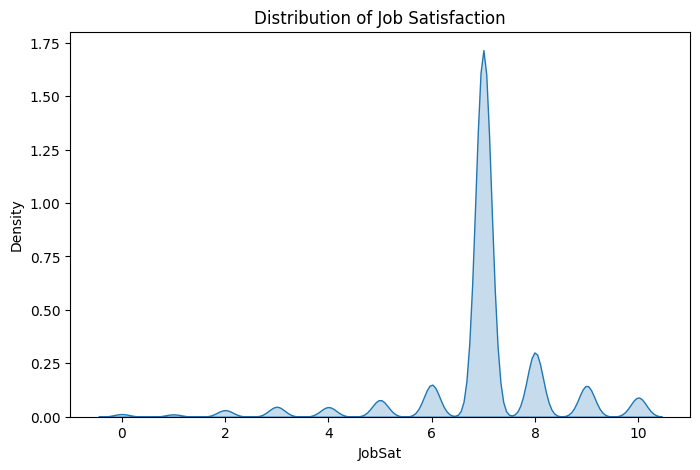

Most respondents are concentrated around 7 (higher JobSat values). This suggests that overall job satisfaction is generally high.


In [7]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['JobSat'].dropna(), fill=True)
plt.title('Distribution of Job Satisfaction')
plt.xlabel('JobSat')
plt.ylabel('Density')
plt.show()

print("Most respondents are concentrated around 7 (higher JobSat values). This suggests that overall job satisfaction is generally high.")

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


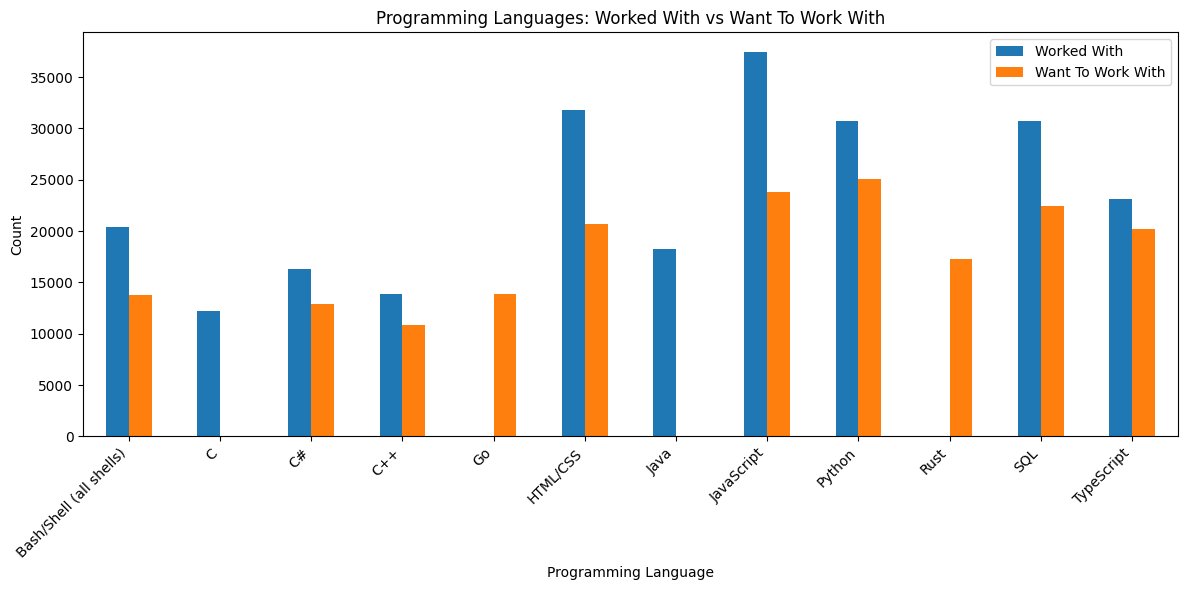

                         Worked With  Want To Work With
Bash/Shell (all shells)      20412.0            13744.0
C                            12184.0                0.0
C#                           16318.0            12921.0
C++                          13827.0            10873.0
Go                               0.0            13837.0
HTML/CSS                     31816.0            20721.0
Java                         18239.0                0.0
JavaScript                   37492.0            23774.0
Python                       30719.0            25047.0
Rust                             0.0            17232.0
SQL                          30682.0            22400.0
TypeScript                   23150.0            20239.0


In [8]:
worked = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode().str.strip()
want = df['LanguageWantToWorkWith'].dropna().str.split(';').explode().str.strip()

worked_counts = worked.value_counts().head(10)
want_counts = want.value_counts().head(10)

language_compare = pd.DataFrame({
    'Worked With': worked_counts,
    'Want To Work With': want_counts
}).fillna(0)

language_compare.plot(kind='bar', figsize=(12, 6))
plt.title('Programming Languages: Worked With vs Want To Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(language_compare)

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


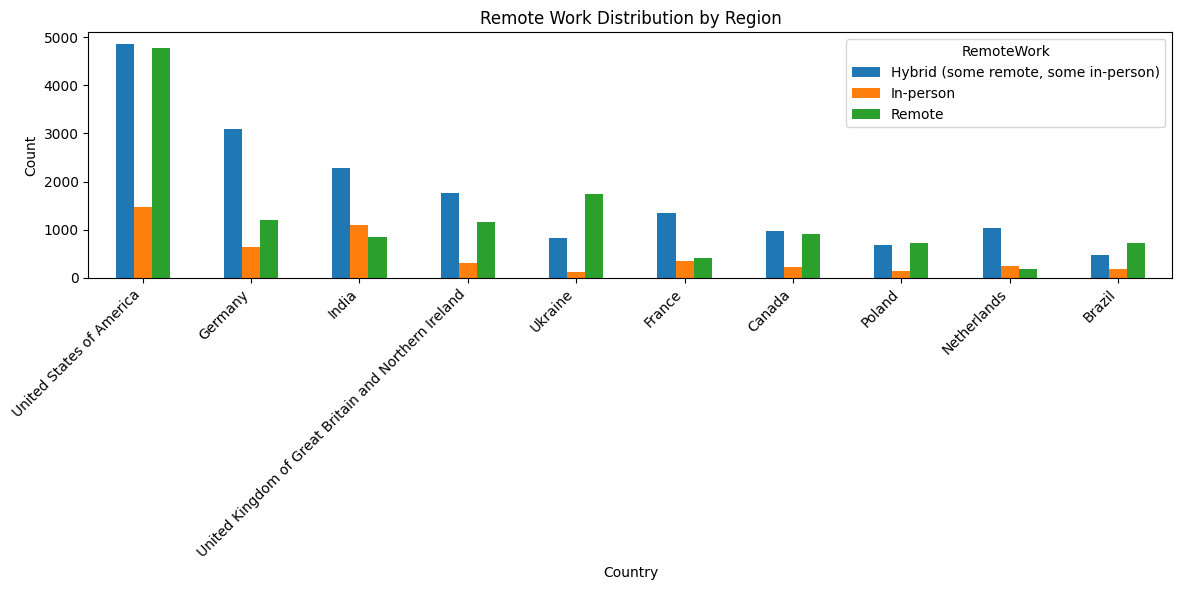

RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
United States of America                                                            4857   
Germany                                                                             3098   
India                                                                               2290   
United Kingdom of Great Britain and Northern Ir...                                  1765   
Ukraine                                                                              828   
France                                                                              1344   
Canada                                                                               970   
Poland                                                                               686   
Netherlands                                                                     

In [9]:
remote_region = pd.crosstab(df['Country'], df['RemoteWork'])

top_countries = df['Country'].value_counts().head(10).index
remote_region_top = remote_region.loc[top_countries]

remote_region_top.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.title('Remote Work Distribution by Region')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(remote_region_top)

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 193.7 MB/s eta 0:00:00


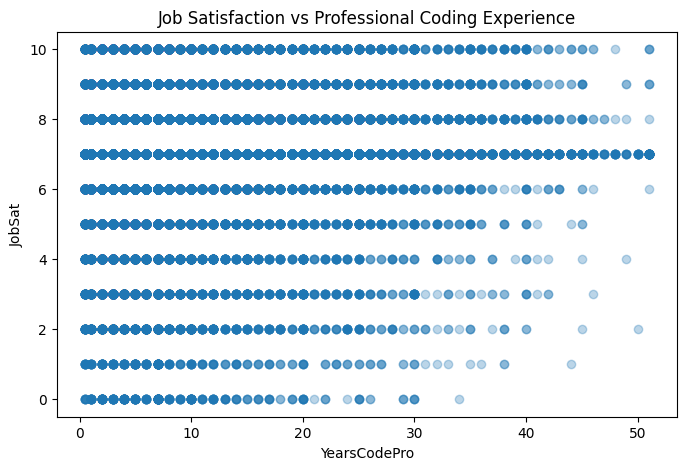

Pearson correlation: 0.06993616834584185
Spearman correlation: 0.09074418034330173


In [11]:
!pip install scipy

df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})

df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

corr_data = df[['YearsCodePro', 'JobSat']].dropna()

pearson_corr = corr_data['YearsCodePro'].corr(corr_data['JobSat'], method='pearson')
spearman_corr = corr_data['YearsCodePro'].corr(corr_data['JobSat'], method='spearman')

plt.figure(figsize=(8, 5))
plt.scatter(corr_data['YearsCodePro'], corr_data['JobSat'], alpha=0.3)
plt.title('Job Satisfaction vs Professional Coding Experience')
plt.xlabel('YearsCodePro')
plt.ylabel('JobSat')
plt.show()

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


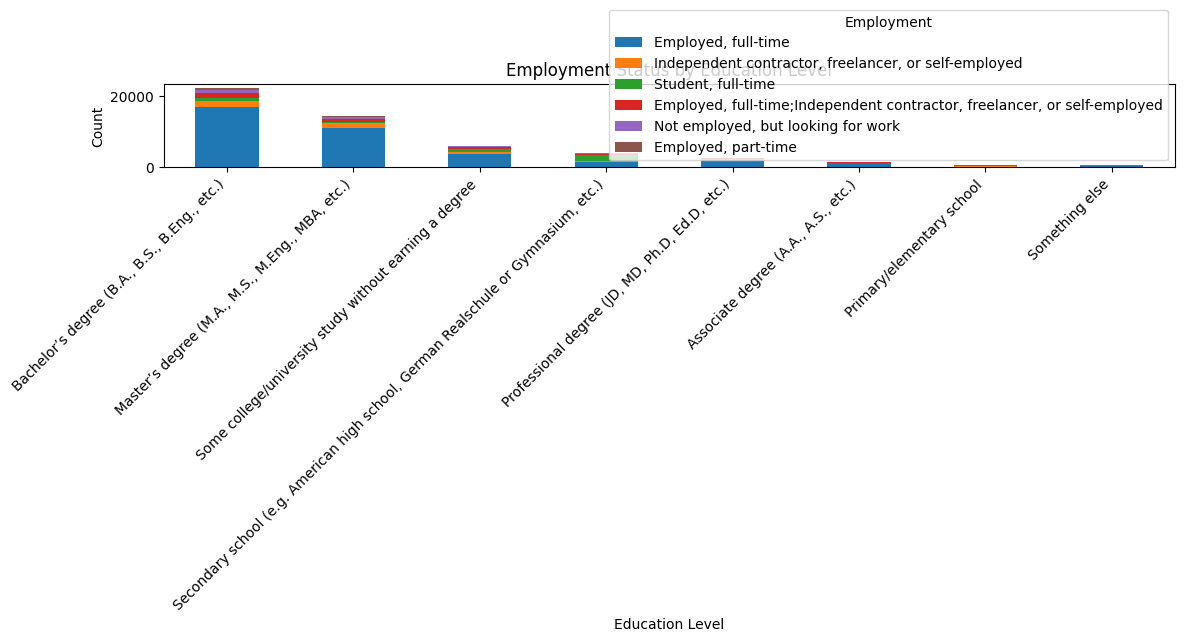

Employment                                          Employed, full-time  \
EdLevel                                                                   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Some college/university study without earning a...                 3579   
Secondary school (e.g. American high school, Ge...                 1460   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Associate degree (A.A., A.S., etc.)                                1059   
Primary/elementary school                                           160   
Something else                                                      377   

Employment                                          Independent contractor, freelancer, or self-employed  \
EdLevel                                                                                                    
Bachelor’s degree (B.A., B.S., B.

In [12]:
employment_edu = pd.crosstab(df['EdLevel'], df['Employment'])

top_edlevels = df['EdLevel'].value_counts().head(8).index
top_employment = df['Employment'].value_counts().head(6).index

employment_edu_top = employment_edu.loc[top_edlevels, top_employment]

employment_edu_top.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(employment_edu_top)

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
